<a href="https://colab.research.google.com/github/Risqullah/Probstat_kelompok4-/blob/main/Analisis_Data_Kelompok_04_Terpisah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Library & Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Membaca dataset Excel
df = pd.read_excel('3TIA_04_DLSS5Study2.xlsx', sheet_name='Dataset_50_Rows')

# Membuang baris ke-51 (Rata-rata) agar tidak mengganggu analisis
df = df.iloc[:50]

# Mengisi nilai kosong pada kolom Visual_Artifacts dengan 'None'
df['Visual_Artifacts'] = df['Visual_Artifacts'].fillna('None')

print(f"Bentuk data setelah cleaning: {df.shape}")
print("\nInfo Dataset:")
df.info()


Bentuk data setelah cleaning: (50, 6)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Responden      50 non-null     object 
 1   Game_Title        50 non-null     object 
 2   Preset_DLSS       50 non-null     object 
 3   Performa_FPS      50 non-null     float64
 4   Skor_MOS          50 non-null     float64
 5   Visual_Artifacts  50 non-null     object 
dtypes: float64(2), object(4)
memory usage: 2.5+ KB


# 2. Statistika Deskriptif
Sel ini menghitung nilai rata-rata, standar deviasi, dan nilai rentang dari data performa (FPS) dan grafis (MOS).

In [2]:
print("--- Ringkasan Statistik Keseluruhan per Preset ---")
desc_stats = df.groupby('Preset_DLSS')[['Performa_FPS', 'Skor_MOS']].describe()
print(desc_stats.to_string())

print("\n--- Rata-rata FPS dan Skor MOS per Judul Game ---")
game_stats = df.groupby(['Game_Title', 'Preset_DLSS'])[['Performa_FPS', 'Skor_MOS']].mean().reset_index()
print(game_stats.to_string(index=False))


--- Ringkasan Statistik Keseluruhan per Preset ---
                       Performa_FPS                                                 Skor_MOS                                          
                              count    mean       std   min   25%   50%   75%   max    count   mean       std  min  25%  50%  75%  max
Preset_DLSS                                                                                                                           
DLSS Cinematic Quality         25.0  46.200  7.897626  31.1  39.6  48.7  53.0  57.2     25.0  4.476  0.420595  3.6  4.2  4.5  4.8  5.0
Native                         25.0  55.472  3.225616  50.3  52.1  56.7  57.9  59.8     25.0  3.572  0.581320  2.6  3.2  3.5  3.7  4.8

--- Rata-rata FPS dan Skor MOS per Judul Game ---
                     Game_Title            Preset_DLSS  Performa_FPS  Skor_MOS
           Downhill: Domination DLSS Cinematic Quality         47.52      4.58
           Downhill: Domination                 Native         57

# 3. Visualisasi Data
Sel ini membuat grafik Boxplot dan Bar Chart untuk membandingkan Native dan DLSS.

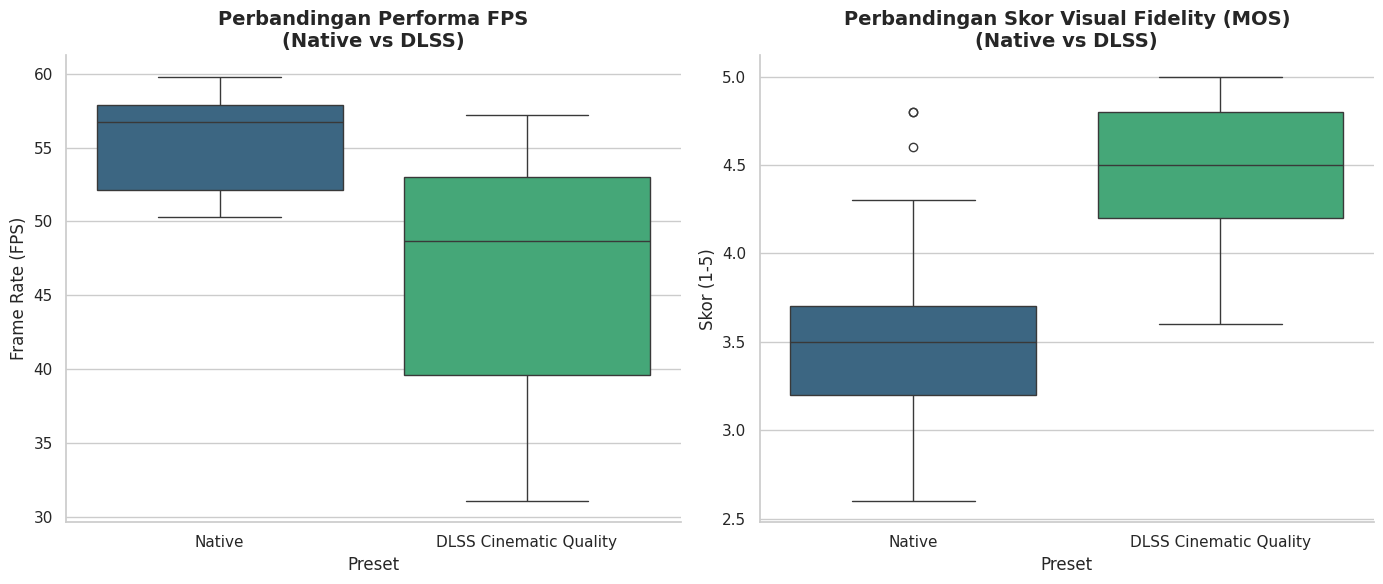

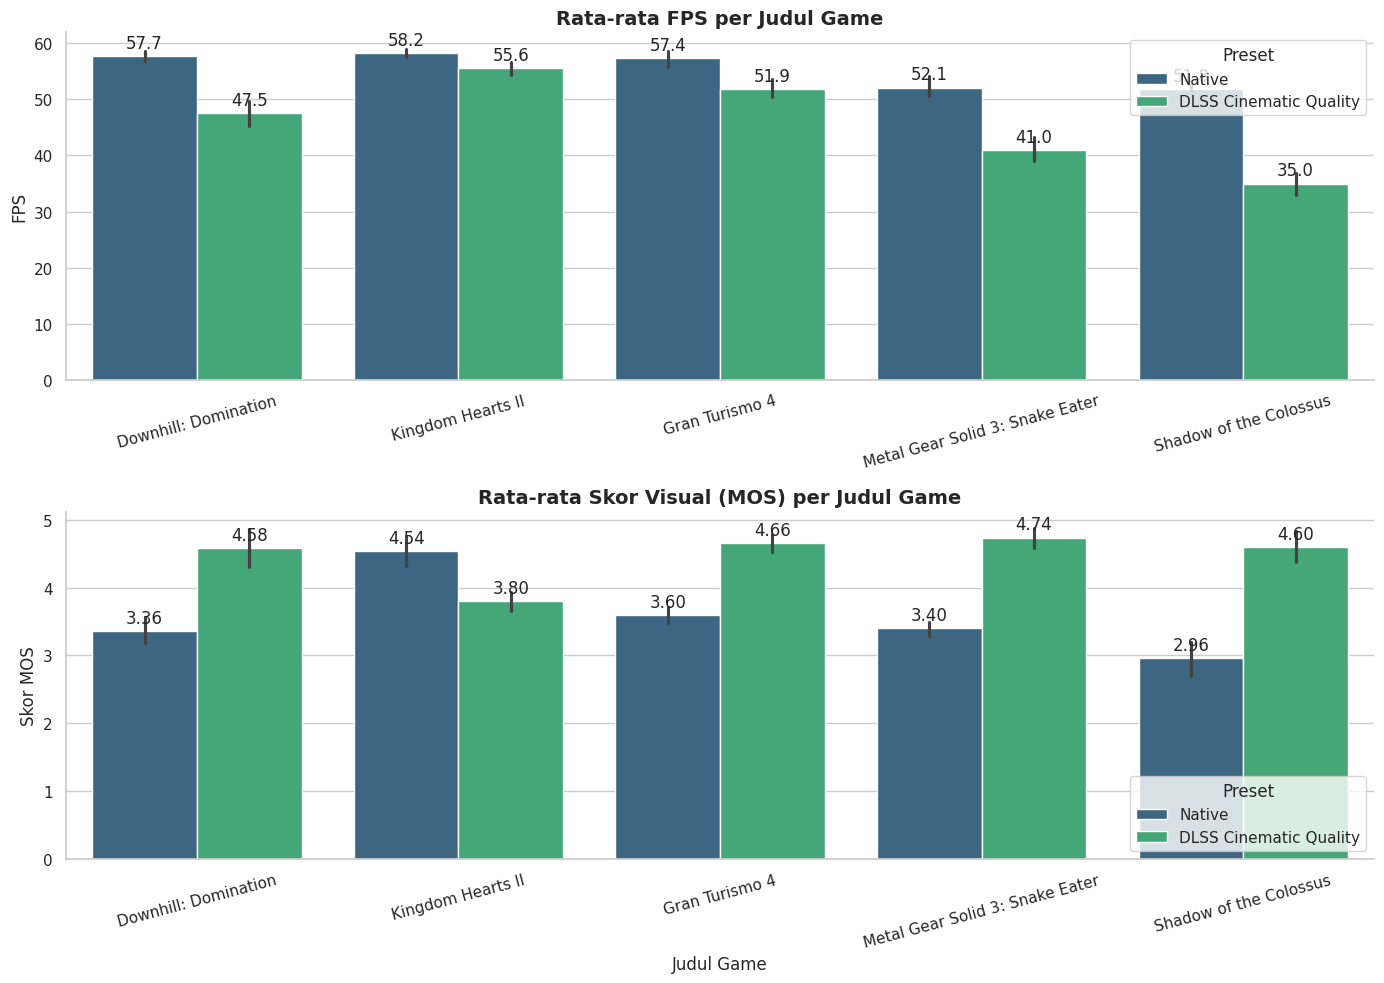

In [7]:
# Konfigurasi tema: background bersih tanpa garis tepi atas dan kanan
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# --- FIGURE 1: BOXPLOT ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Menggunakan parameter hue dan legend=False untuk menghilangkan FutureWarning
sns.boxplot(data=df, x='Preset_DLSS', y='Performa_FPS', hue='Preset_DLSS', legend=False, palette='viridis')
plt.title('Perbandingan Performa FPS\n(Native vs DLSS)', fontsize=14, fontweight='bold')
plt.xlabel('Preset', fontsize=12)
plt.ylabel('Frame Rate (FPS)', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Preset_DLSS', y='Skor_MOS', hue='Preset_DLSS', legend=False, palette='viridis')
plt.title('Perbandingan Skor Visual Fidelity (MOS)\n(Native vs DLSS)', fontsize=14, fontweight='bold')
plt.xlabel('Preset', fontsize=12)
plt.ylabel('Skor (1-5)', fontsize=12)

plt.tight_layout()
plt.show()

# --- FIGURE 2: BAR CHART PER GAME ---
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=df, x='Game_Title', y='Performa_FPS', hue='Preset_DLSS', palette='viridis')
plt.title('Rata-rata FPS per Judul Game', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('FPS', fontsize=12)
plt.legend(title='Preset', loc='upper right')
plt.xticks(rotation=15)
# Menambahkan label angka di atas batang
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', padding=3)

plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=df, x='Game_Title', y='Skor_MOS', hue='Preset_DLSS', palette='viridis')
plt.title('Rata-rata Skor Visual (MOS) per Judul Game', fontsize=14, fontweight='bold')
plt.xlabel('Judul Game', fontsize=12)
plt.ylabel('Skor MOS', fontsize=12)
plt.legend(title='Preset', loc='lower right')
plt.xticks(rotation=15)
# Menambahkan label angka di atas batang
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

# 4. Statistika Inferensial (Paired T-Test)
Sel ini menguji apakah perbedaan antara Native dan DLSS signifikan secara statistik (p-value < 0.05).

In [4]:
native_fps = df[df['Preset_DLSS'] == 'Native']['Performa_FPS'].values
dlss_fps = df[df['Preset_DLSS'] == 'DLSS Cinematic Quality']['Performa_FPS'].values

native_mos = df[df['Preset_DLSS'] == 'Native']['Skor_MOS'].values
dlss_mos = df[df['Preset_DLSS'] == 'DLSS Cinematic Quality']['Skor_MOS'].values

# Uji hipotesis
t_stat_fps, p_val_fps = stats.ttest_rel(native_fps, dlss_fps)
print("--- HASIL UJI T BERPASANGAN (PAIRED T-TEST) ---")
print(f"FPS -> t-statistic: {t_stat_fps:.3f}, p-value: {p_val_fps:.3e}")

t_stat_mos, p_val_mos = stats.ttest_rel(native_mos, dlss_mos)
print(f"MOS -> t-statistic: {t_stat_mos:.3f}, p-value: {p_val_mos:.3e}")


--- HASIL UJI T BERPASANGAN (PAIRED T-TEST) ---
FPS -> t-statistic: 8.071, p-value: 2.696e-08
MOS -> t-statistic: -4.965, p-value: 4.541e-05
